In [ ]:
# Mock Data Generator (Smart Conveyor Monitoring System)
Simulates FB1 tag shape (Motor_Run, SystemReady, FaultActive, ItemCount,
TempAlarmHigh, TempAlarmLow) using a random-walk temperature model.
OPC-UA live feed is architecturally blocked (see project README) —
this generates realistic mock data so CSV logging / alarm detection /
dashboard can be built and tested now.
## CSV Logging
Appends readings to a persistent log (real historian behavior — survives
kernel restarts, never auto-wiped). Uses csv.DictWriter for safe column
alignment.
## """Full pipeline demo: generate -> print -> log -> sleep -> repeat."""

In [27]:
import time
import random
import csv
import os
from datetime import datetime

In [28]:
def initial_state():
    """Starting values for one mock conveyor. Call once per machine."""
    return{
    "temp": 22.0,
    "item_count": 0,
    "fault_active": False,
    }

In [29]:
def next_reading(state, fault_chance=0.02, reset_fault=False):
    """
    Advance one mock conveyor by a single time step.
    Returns a NEW state dict — does not mutate the input.
    """
    fault_active = state["fault_active"]
    if reset_fault:
        fault_active = False
    elif not fault_active and random.random() < fault_chance:
        fault_active = True

    step = random.uniform(-0.5, 0.5)
    new_temp = state["temp"] + step
    new_temp = max(0.0, min(95.0, new_temp)) # keep in physically plausible range
    new_temp = round(new_temp, 2) #realistic sensor precision, not 15 decimals

    temp_alarm_high = new_temp > 80.0
    temp_alarm_low = new_temp < 5.0
  
    motor_run = not fault_active
    item_count = state["item_count"]
    if motor_run:
        item_count += 1
        if item_count > 9999:
            item_count = 0

    system_ready = (not fault_active) and (not temp_alarm_high) and (not temp_alarm_low)

    return{
    "temp" : new_temp,
    "item_count" : item_count,
    "fault_active" : fault_active,
    "motor_run" : motor_run,
    "system_ready" : system_ready,
    "temp_alarm_high" : temp_alarm_high,
    "temp_alarm_low" : temp_alarm_low,
    }

In [30]:
LOG_FILE = "pipeline_test.csv"
FIELDNAMES = ["timestamp", "temp", "item_count", "motor_run", "system_ready", "fault_active", "temp_alarm_high", "temp_alarm_low"]

def log_reading(state, log_file=LOG_FILE):
    """Append one conveyor reading to the persistent CSV log.
    Writes the header row only if the file doesn't exist yet.
    """
    file_exists = os.path.exists(log_file)
    with open(log_file, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if not file_exists:
            writer.writeheader()
        row = {"timestamp": datetime.now().isoformat(timespec="seconds")}
        row.update(state)
        writer.writerow(row)

In [31]:
def run_pipeline(num_readings=5, poll_interval=1, fault_chance=0.2, reset_at=None):
    """Run the mock pipeline: generate, display, log, wait, repeat.
    Args:
        reset_at: set of iteration indices at which to reset an active
                   fault (simulates an operator/E-Stop reset). None or
                   empty = fault stays latched once triggered.
    """
    if reset_at is None:
        reset_at = set()
    state = initial_state()
    for i in range(num_readings):
        do_reset = i in reset_at
        state = next_reading(state, fault_chance=fault_chance, reset_fault=do_reset)
        status = "FAULT!" if state ["fault_active"] else "ok"
        print(f"[{i}] temp={state['temp']:6.2f} count={state['item_count']:3d} status={status}")
        log_reading(state)
        if i < num_readings -1:
            time.sleep(poll_interval)
    print("Pipeline run complete. Logged to", LOG_FILE)

if __name__=="__main__":
    if os.path.exists(LOG_FILE):
        os.remove(LOG_FILE) #clean slate for this demo only
    run_pipeline(num_readings=20, poll_interval=1, fault_chance=0.2, reset_at={10})

[0] temp= 22.15 count=  1 status=ok
[1] temp= 22.36 count=  2 status=ok
[2] temp= 22.38 count=  3 status=ok
[3] temp= 22.48 count=  3 status=FAULT!
[4] temp= 22.28 count=  3 status=FAULT!
[5] temp= 21.99 count=  3 status=FAULT!
[6] temp= 21.54 count=  3 status=FAULT!
[7] temp= 21.44 count=  3 status=FAULT!
[8] temp= 21.07 count=  3 status=FAULT!
[9] temp= 21.28 count=  3 status=FAULT!
[10] temp= 21.01 count=  4 status=ok
[11] temp= 21.24 count=  5 status=ok
[12] temp= 20.88 count=  6 status=ok
[13] temp= 21.00 count=  7 status=ok
[14] temp= 21.45 count=  8 status=ok
[15] temp= 21.75 count=  9 status=ok
[16] temp= 21.38 count=  9 status=FAULT!
[17] temp= 21.42 count=  9 status=FAULT!
[18] temp= 21.90 count=  9 status=FAULT!
[19] temp= 22.32 count=  9 status=FAULT!
Pipeline run complete. Logged to pipeline_test.csv


In [32]:
def analyze_log(log_file=LOG_FILE, n_consecutive=3):
    """Detect sustained high-temp alarms: N consecutive readings over threshold."""
    high_streak = 0
    low_streak = 0
    high_alarmed = False
    low_alarmed = False
    alarms = []

    with open(log_file, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["temp_alarm_high"] == "True":
                high_streak += 1
            else:
                high_streak = 0
                high_alarmed = False
                
            if row["temp_alarm_low"] == "True":
                low_streak += 1
            else:
                low_streak = 0
                low_alarmed = False

            if high_streak >= n_consecutive and not high_alarmed:
                alarms.append((row["timestamp"], "HIGH"))
                high_alarmed = True
                
            if low_streak >= n_consecutive and not low_alarmed:
                alarms.append((row["timestamp"], "LOW"))
                low_alarmed = True

    return alarms

print(analyze_log())

[]


In [33]:
# Isolated test for analyze_log() — hand-built CSV, no randomness.
# Deliberately contains a known 4-row streak of temp_alarm_high == True,
# broken by a False row, to prove both detection AND reset work.

test_file = "test_alarm.csv"

test_rows = [
    {"timestamp": "t0", "temp": "75.0", "item_count": "1", "motor_run": "True",
     "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "False"},
    {"timestamp": "t1", "temp": "81.0", "item_count": "2", "motor_run": "True",
     "system_ready": "False", "fault_active": "False",
     "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "t2", "temp": "82.0", "item_count": "3", "motor_run": "True",
     "system_ready": "False", "fault_active": "False",
     "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "t3", "temp": "83.0", "item_count": "4", "motor_run": "True",
     "system_ready": "False", "fault_active": "False",
     "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "t4", "temp": "70.0", "item_count": "5", "motor_run": "True",
     "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "False"},
    {"timestamp": "t5", "temp": "4.9", "item_count": "6", "motor_run": "True",
    "system_ready": "False", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
    {"timestamp": "t6", "temp": "4.5", "item_count": "7", "motor_run": "True",
    "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
    {"timestamp": "t7", "temp": "4.3", "item_count": "8", "motor_run": "True",
    "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
        {"timestamp": "t8", "temp": "4.6", "item_count": "9", "motor_run": "True",
     "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
    {"timestamp": "t9", "temp": "4.2", "item_count": "10", "motor_run": "True",
     "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
    {"timestamp": "t10", "temp": "4.4", "item_count": "11", "motor_run": "True",
     "system_ready": "True", "fault_active": "False",
     "temp_alarm_high": "False", "temp_alarm_low": "True"},
]

with open(test_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    writer.writeheader()
    writer.writerows(test_rows)

print(analyze_log(log_file=test_file, n_consecutive=3))

[('t3', 'HIGH'), ('t7', 'LOW')]


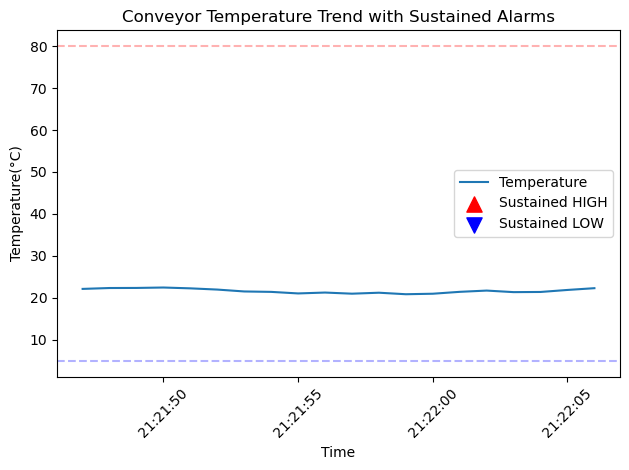

In [34]:
import matplotlib.pyplot as plt

LOG_FILE = "pipeline_test.csv"

temp_list = []
timestamp = []

with open(LOG_FILE, "r")as f:
    reader = csv.DictReader(f)
    for row in reader:
        temp_list.append(float(row["temp"]))
        timestamp.append(datetime.fromisoformat(row["timestamp"]))

# ---locate each sustained alarm's (x, y) position ---
alarms = analyze_log(LOG_FILE)

high_x, high_y = [], []
low_x, low_y = [], []

for ts_string, label in alarms:
    ts = datetime.fromisoformat(ts_string)
    idx = timestamp.index(ts)
    temp_at_alarm = temp_list[idx]
    if label == "HIGH":
        high_x.append(ts)
        high_y.append(temp_at_alarm)
    else:
        low_x.append(ts)
        low_y.append(temp_at_alarm)

plt.plot(timestamp, temp_list, label="Temperature")
# --- scatter markers + threshold lines ---
plt.scatter(high_x, high_y, color="red", marker="^", s=120, label="Sustained HIGH", zorder=5)
plt.scatter(low_x, low_y, color="blue", marker="v", s=120, label="Sustained LOW", zorder=5)
plt.axhline(80, color="red", linestyle="--", alpha=0.3)
plt.axhline(5, color="blue", linestyle="--", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Temperature(°C)")
plt.title("Conveyor Temperature Trend with Sustained Alarms")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Expected: one HIGH alarm at 2026-08-24T10:00:08 (3rd consecutive >80, temp=84)
Actual:   [('2026-08-24T10:00:08', 'HIGH')]


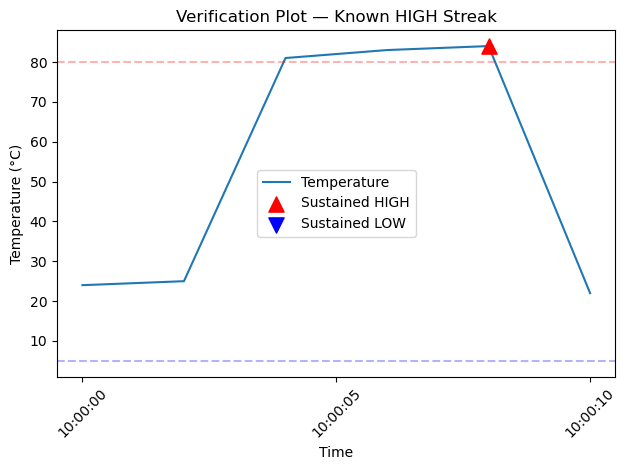

In [35]:
# --- Verification: hand-built fixture with a known HIGH streak ---
# Proves the marker-overlay logic (not just analyze_log) correctly
# locates and plots the alarm at the right (time, temp) coordinate.

verify_file = "dashboard_verify.csv"

verify_rows = [
    {"timestamp": "2026-08-24T10:00:00", "temp": "24", "item_count": "0", "motor_run": "True",
     "system_ready": "True", "fault_active": "False", "temp_alarm_high": "False", "temp_alarm_low": "False"},
    {"timestamp": "2026-08-24T10:00:02", "temp": "25", "item_count": "1", "motor_run": "True",
     "system_ready": "True", "fault_active": "False", "temp_alarm_high": "False", "temp_alarm_low": "False"},
    {"timestamp": "2026-08-24T10:00:04", "temp": "81", "item_count": "2", "motor_run": "True",
     "system_ready": "False", "fault_active": "False", "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "2026-08-24T10:00:06", "temp": "83", "item_count": "3", "motor_run": "True",
     "system_ready": "False", "fault_active": "False", "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "2026-08-24T10:00:08", "temp": "84", "item_count": "4", "motor_run": "True",
     "system_ready": "False", "fault_active": "False", "temp_alarm_high": "True", "temp_alarm_low": "False"},
    {"timestamp": "2026-08-24T10:00:10", "temp": "22", "item_count": "5", "motor_run": "True",
     "system_ready": "True", "fault_active": "False", "temp_alarm_high": "False", "temp_alarm_low": "False"},
]

with open(verify_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    writer.writeheader()
    writer.writerows(verify_rows)

# Re-run the exact same plotting logic, pointed at the fixture instead of LOG_FILE
temp_list_v = []
timestamp_v = []
with open(verify_file, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        temp_list_v.append(float(row["temp"]))
        timestamp_v.append(datetime.fromisoformat(row["timestamp"]))

alarms_v = analyze_log(verify_file)
print("Expected: one HIGH alarm at 2026-08-24T10:00:08 (3rd consecutive >80, temp=84)")
print("Actual:  ", alarms_v)

# --- Plot the verification fixture to visually confirm marker placement ---
high_x_v, high_y_v = [], []
low_x_v, low_y_v = [], []

for ts_string, label in alarms_v:
    ts = datetime.fromisoformat(ts_string)
    idx = timestamp_v.index(ts)
    temp_at_alarm = temp_list_v[idx]
    if label == "HIGH":
        high_x_v.append(ts)
        high_y_v.append(temp_at_alarm)
    else:
        low_x_v.append(ts)
        low_y_v.append(temp_at_alarm)

plt.plot(timestamp_v, temp_list_v, label="Temperature")
plt.scatter(high_x_v, high_y_v, color="red", marker="^", s=120, label="Sustained HIGH", zorder=5)
plt.scatter(low_x_v, low_y_v, color="blue", marker="v", s=120, label="Sustained LOW", zorder=5)
plt.axhline(80, color="red", linestyle="--", alpha=0.3)
plt.axhline(5, color="blue", linestyle="--", alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Verification Plot — Known HIGH Streak")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Summary — Mock Data Generator
- Built `next_reading()`: random-walk temp (not fresh-random) so alarm
  detection can be tested against continuous, physically plausible data.
- State passed as dict in/out (not global) — enables multi-machine sim later.
- Fault latches until explicit `reset_fault=True` — matches FB1's
  reset-dominant E-Stop behavior.
- Temp clamped [0, 95] — prevents unbounded random-walk drift outside
  any real conveyor's operating range.
- Rounded to round(temp, 2) at the source — realistic sensor precision.

In [ ]:
## Summary — CSV Logging
- Diagnosed "w" mode inside a loop truncating the file each write — only
  last row survived. Fixed by opening once (or using "a" append mode).
- Chose append mode ("a") over fresh-write ("w") to match real historian
  behavior: data persists across kernel restarts, never silently wiped.
- csv.DictWriter matches columns by field name, not position — avoids
  silent column-misalignment bugs (caught a fieldname typo at write-time
  instead of silently writing wrong columns).

In [ ]:
## Summary — Polling Loop (time.sleep)
- Wrapped generator + logger in run_pipeline(num_readings, poll_interval,
  fault_chance) — reusable, adjustable via parameters.
- time.sleep() placed INSIDE the for loop (after print+log, before next
  iteration) — placing it outside the loop only runs it once total,
  not once per reading. Confirmed via broken-vs-correct comparison.
- Skip sleep after the final reading (if i < num_readings - 1) — avoids
  a pointless wait with nothing left to do.
- This loop shape (read -> report -> log -> wait -> repeat) matches a
  real OPC-UA polling client — next_reading() is the only piece that
  changes when live PLCSIM connectivity is eventually available.

In [ ]:
## Concept: if __name__ == "__main__"
- __name__ is a variable Python sets automatically per file.
- Running a file directly -> __name__ == "__main__" -> block runs.
- Importing the file from elsewhere -> __name__ == filename -> block
  is skipped, but function/class definitions above it still load.
- Prevents test/demo code from firing automatically when this file's
  functions get reused (e.g. imported into a future dashboard script).

In [ ]:
## Fix — Fault Reset Bug
- Found: reset_fault=True cleared fault_active, but the SAME function
  call then immediately re-checked random.random() < fault_chance,
  which could re-trigger a fault in the same instant as the reset —
  physically impossible (an E-Stop reset and a new fault can't
  coincide in the same moment).
- Root cause: two separate `if` blocks let both run in one call.
- Fix: changed to if/elif inside next_reading() — reset and new-fault
  check are now mutually exclusive, enforced at the function itself
  (not just in run_pipeline()) so ALL future callers get correct
  behavior, not only ones that happen to route through run_pipeline().
- Added reset_at parameter to run_pipeline() — lets callers specify
  which iteration(s) simulate an operator reset.

In [ ]:
## Summary — analyze_log() (Sustained Alarm Detection, fire-once)
- csv.DictReader returns ALL values as strings — no auto type conversion.
  Booleans read back as "True"/"False" text; `if row["field"]:` is
  always True for any non-empty string. Must compare explicitly:
  row["field"] == "True".
- Two independent streak counters (high_streak, low_streak), each
  resetting to 0 when its own condition is False — including when the
  OTHER condition is True (mutually exclusive by design).
- Fire-once-per-event: high_alarmed / low_alarmed flags block repeat
  appends while a streak persists past n_consecutive. Flag resets
  alongside its streak the moment the condition breaks, allowing the
  next genuine sustained event to alarm again.
- Verified against real pipeline_test.csv (empty result — data never
  crossed thresholds) AND hand-built test_alarm.csv with known HIGH
  (t1-t3) and LOW (t5-t10) streaks — confirmed single alarm entry per
  event, not one per row, including across a 6-row sustained LOW run.

In [ ]:
## Summary — Dashboard (Matplotlib Trend Plot + Alarm Markers)
- Built a static matplotlib plot: temperature vs. real timestamp, with
  sustained HIGH/LOW alarms from analyze_log() overlaid as markers.
- Two parallel lists (temp_list, timestamp) built from the CSV in one
  read pass — same pattern as analyze_log()'s row loop, reused for
  plotting instead of streak-counting.
- csv.DictReader returns strings for everything, same gotcha as the
  boolean fields earlier — temp needed float(), timestamp needed
  datetime.fromisoformat(). Plotting raw ISO strings directly works
  for small test files but produces an unreadable/misleading axis on
  real multi-row logs (matplotlib treats them as categorical labels,
  not real elapsed time).
- Alarm markers found via list.index(): converted each alarm's
  timestamp string (from analyze_log()) to a datetime, located its
  position in the timestamp list, then pulled the matching value from
  temp_list at that same index — the two lists stay aligned because
  they're built in the same loop pass.
- Verified two ways: (1) against real pipeline_test.csv — correctly
  produced a clean line with zero markers, since no run yet has held
  above 80°C or below 5°C for 3 consecutive readings; (2) against a
  hand-built fixture (dashboard_verify.csv) with a known 3-row HIGH
  streak — marker landed exactly on the 3rd consecutive reading
  (temp=84), matching analyze_log()'s fire-once behavior.